# **Team Name:** `B Team`
# **Authors:** `Madelyne Dusbabek, Gregory Lowman, Jay Hall`
# **Cell Number:** `R22`
# **J-V Apparatus Number:** `JV 1`
# **EQE Apparatus Number:** `EQE 1`

\### This week you will do the following data analysis:

1.   Calculate PCE values and uncertainties for all pixels. Write the PCE values, PCE uncertainties, and $J_{sc}$ values to a CSV file. **You have done this analysis in previous Colab notebooks. Please copy, edit, and reuse your code from previous weeks.**

2.   Fit a weighted linear regression to the PCE values for one pixel over time, then compare weighted linear fits for two pixels.




## **PCE Analysis**

1. Calculate the $J_{sc}$ and PCE values for each pixel. Remember to follow the uncertainty workflow from Data Collection 2: create power vs. voltage plots, estimate $dV_{pmax}$ and $dJ_{pmax}$, and propagate uncertainties to produce your final CSV with `PCE_uncertainty (%)`.

2. Update the PCE plot you made last week to include this week's PCE values and error bars. This figure should now have **six** time points: baseline data, Data Collection 1, Data Collection 2, break week (TA data), Data Collection 3, and Data Collection 4 (this week). **Remember to update the time values for this week's data.**

In [1]:
# Week 7
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

AREA = 0.14  # cm^2

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/JV_Data"

if not os.path.exists(folder):
    raise FileNotFoundError(f"Folder not found:\n{folder}")

files = sorted(
    f for f in os.listdir(folder)
    if f.endswith(".csv") and "_IV_cell" in f and "_pixel" in f
)

if not files:
    raise SystemExit("No JV files found in folder.")

jv_data = {}

for f in files:
    full_path = os.path.join(folder, f)
    df = pd.read_csv(full_path)

    df.columns = df.columns.str.strip()

    # Verify required columns exist
    required_cols = ["Voltage (V)", "Forward_mean (mA)"]
    if not all(col in df.columns for col in required_cols):
        print(f"[skip] Unexpected format: {f}")
        continue

    name = f.replace(".csv", "")

    jv_data[name] = pd.DataFrame({
        "Voltage (V)": pd.to_numeric(df["Voltage (V)"], errors="coerce"),
        "Current Density (mA/cm^2)":
            pd.to_numeric(df["Forward_mean (mA)"], errors="coerce") / AREA
    })

print(f"[ok] Loaded {len(jv_data)} JV files")

###############################################################################

date_str = "2026_03_10"
cell_id  = "R22"
area_cm2 = 0.14
P_in = 99.8
pixels = range(1, 9)

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/JV_Data"

COL_V          = "Voltage (V)"
COL_Forward_mA = "Forward_mean (mA)"
COL_Fwd_std    = "Forward_std (mA)"
COL_Fwd_n      = "Forward_n"

raw_data = {}
jv_data  = {}

for n in pixels:
    fname = f"{date_str}_IV_cell{cell_id}_pixel{n}.csv"
    try:
        df_raw = pd.read_csv(os.path.join(folder, fname))
        raw_data[n] = df_raw

        df_jv = pd.DataFrame({
            "Voltage (V)": df_raw[COL_V].astype(float),
            "Current Density (mA/cm^2)": df_raw[COL_Forward_mA].astype(float) / area_cm2
        }).sort_values("Voltage (V)").reset_index(drop=True)

        df_jv["Power Density (mW/cm^2)"] = (
            df_jv["Voltage (V)"] * df_jv["Current Density (mA/cm^2)"]
        )

        jv_data[n] = df_jv
        print(f"[ok] Loaded pixel {n}")

    except FileNotFoundError:
        print(f"[skip] Pixel {n}: file not found ({fname})")
    except Exception as e:
        print(f"[skip] Pixel {n}: error reading {fname}: {e}")

rows = []
valid_pixels = sorted(jv_data.keys())

for n in valid_pixels:
    jv  = jv_data[n]
    raw = raw_data[n].sort_values(COL_V).reset_index(drop=True)

    V = jv["Voltage (V)"].to_numpy()
    J = jv["Current Density (mA/cm^2)"].to_numpy()

    Voc = float(np.interp(0.0, J, V))
    Jsc = float(np.interp(0.0, V, J))
    P   = V * J
    idx_pmax = int(np.argmin(P))
    Vmp = float(V[idx_pmax])
    Jmp = float(J[idx_pmax])

    denom = abs(Jsc) * Voc
    FF  = (Vmp * abs(Jmp)) / denom if denom != 0 else np.nan
    PCE = ((Voc * abs(Jsc) * FF) / P_in) * 100 if P_in != 0 else np.nan

    std_mA_mpp = float(raw[COL_Fwd_std].iloc[idx_pmax])
    n_mpp      = float(raw[COL_Fwd_n].iloc[idx_pmax])

    if n_mpp > 1:
        SE_I_mpp = std_mA_mpp / np.sqrt(n_mpp)
        SE_J_mpp = SE_I_mpp / area_cm2
    else:
        SE_J_mpp = np.nan
        print(f"  [warn] Pixel {n}: n=1 at MPP, SE undefined")

    idx_v0 = int(np.argmin(np.abs(raw[COL_V].to_numpy())))
    std_mA_v0 = float(raw[COL_Fwd_std].iloc[idx_v0])
    n_v0      = float(raw[COL_Fwd_n].iloc[idx_v0])

    if n_v0 > 1:
        SE_Jsc = (std_mA_v0 / np.sqrt(n_v0)) / area_cm2
    else:
        SE_Jsc = np.nan

    if len(V) > 1:
        voltage_step = float(np.median(np.abs(np.diff(V))))
        dV = voltage_step / 2.0
    else:
        dV = np.nan

    rows.append({
        "Pixel Number":        n,
        "Jsc (mA/cm^2)":      Jsc,
        "SE_Jsc (mA/cm^2)":   SE_Jsc,
        "J_pmax (mA/cm^2)":   Jmp,
        "V_pmax (V)":         Vmp,
        "PCE":                PCE,
        "SE_Jpmax (mA/cm^2)": SE_J_mpp,
        "dV (V)":             dV,
        "n_at_MPP":           n_mpp,
    })

out_name = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_jsc_pce_cellR22.csv"
df_out = pd.DataFrame(rows)
df_out.sort_values("Pixel Number").to_csv(out_name, index=False)

if df_out.empty:
    print("[warn] No valid pixels found — did you run the loader above?")
else:
    df_out.sort_values("Pixel Number").to_csv(out_name, index=False)
    print(f"\n[ok] Wrote {out_name}")
    display(df_out)

Mounted at /content/drive
[ok] Loaded 8 JV files
[ok] Loaded pixel 1
[ok] Loaded pixel 2
[ok] Loaded pixel 3
[ok] Loaded pixel 4
[ok] Loaded pixel 5
[ok] Loaded pixel 6
[ok] Loaded pixel 7
[ok] Loaded pixel 8

[ok] Wrote /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_jsc_pce_cellR22.csv


,Pixel Number,Jsc (mA/cm^2),SE_Jsc (mA/cm^2),J_pmax (mA/cm^2),V_pmax (V),PCE,SE_Jpmax (mA/cm^2),dV (V),n_at_MPP
0,1,-8.738786,0.003580,-7.252357,0.78,5.668175,0.003960,0.01,10.0
1,2,-8.510143,0.005965,-6.896143,0.94,6.495365,0.004165,0.01,10.0
2,3,-9.341143,0.005604,-7.525500,0.94,7.088146,0.004271,0.01,10.0
3,4,-9.725929,0.005631,-7.505000,0.92,6.918437,0.006812,0.01,10.0
4,5,-7.987357,0.004427,-6.523929,0.94,6.144782,0.003729,0.01,10.0
5,6,-14.965214,0.002561,-12.668214,0.96,12.185857,0.004626,0.01,10.0
6,7,-9.256643,0.004764,-7.483500,0.94,7.048587,0.005911,0.01,10.0
7,8,-12.661714,0.004585,-10.341786,0.94,9.740760,0.006081,0.01,10.0


Instead of plotting the values this week, please paste the output of your CSV file. It should have the following columns:

Pixel Number	| Time (hr)	| Jsc (mA/cm^2)	| PCE	| PCE_uncertainty (%)

Paste CSV Output

In [ ]:
#PixelNumber	   Jsc (mA/cm^2)	   SE_Jsc (mA/cm^2)	  J_pmax (mA/cm^2)	V_pmax (V)	  PCE	            SE_Jpmax (mA/cm^2)	    dV (V)	    n_at_MPP
#1	             -8.738785714	      0.003580150065	  -7.252357143	    0.78	        5.668174921	    0.003959623384	        0.01	      10
#2	             -8.510142857	      0.005965410929	  -6.896142857	    0.94	        6.495365016	    0.004165171432	        0.01	      10
#3	             -9.341142857	      0.005604007768	  -7.5255	          0.94	        7.088146293	    0.004271333611	        0.01	      10
#4	             -9.725928571	      0.005631113005	  -7.505	          0.92	        6.918436874	    0.006812449588	        0.01	      10
#5	             -7.987357143	      0.004427188724	  -6.523928571	    0.94	        6.144782422	    0.003729228869	        0.01	      10
#6	             -14.96521429	      0.002561444905	  -12.66821429	    0.96	        12.18585743	    0.004625960463	        0.01	      10
#7	             -9.256642857	      0.004763745418	  -7.4835	          0.94	        7.048587174	    0.005911200455	        0.01	      10
#8	             -12.66171429	      0.004585302607	  -10.34178571	    0.94	        9.740760092	    0.006080608187	        0.01	      10


#### **Question 1:** How do your PCE values from this week compare to the values from previous weeks?

Compared to our Week 6 PCE values it seems that cells 2,3,5,and 7 have all slightly increased, the biggest increase being cell 7 with a 0.27 difference. All of our other cells are decreasing. Compared to week one we can see a constant decrease for all of our cells.

## Introduction to Linear Regression

Linear regression is a statistical method used to model the relationship between variables by fitting a linear equation to observed data. In our case, we want to model how PCE changes over time.

The basic form of a linear regression model is:

$$y = mx + b + \epsilon$$

Where:
- $y$ is the dependent variable (PCE in our case)
- $x$ is the independent variable (time in days)
- $m$ is the slope (rate of change of PCE per day)
- $b$ is the y-intercept (theoretical initial PCE value)
- $\epsilon$ represents random error

### Understanding Chi-Squared (reminders from lecture)

The chi-squared (χ²) statistic is a powerful tool for evaluating the quality of a fit when we have uncertainties in our measurements. It is applicable to many types of data fitting models, not just a linear fit (which is what we are considering today). It's calculated as:

$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - \hat{y}_i)^2}{\sigma_i^2}$$

Where:
- $y_i$ are the observed values
- $\hat{y}_i$ are the predicted values from our model
- $\sigma_i$ are the uncertainties in each measurement

The reduced chi-squared (χ²/ν) divides the chi-squared value by the number of degrees of freedom (ν = n - p, where n is the number of data points and p is the number of parameters in the model):

$$\frac{\chi^2}{\nu} = \frac{\chi^2}{n-p}$$

For a good fit with accurate uncertainties:
- χ²/ν ≈ 1: Indicates a good fit with appropriate uncertainties
- χ²/ν < 1: May indicate overestimated uncertainties or overfitting
- χ²/ν > 1: May indicate underestimated uncertainties or a poor model fit

### Weighted Linear Regression

In this analysis, we use a **weighted linear regression**, which takes into account the uncertainties in each measurement.
Each data point is weighted by the inverse of the square of its uncertainty ($1/\sigma^2$), so points measured with smaller uncertainties have more influence on the fit.
This approach provides a more accurate estimate of the slope and intercept — and lets us calculate meaningful values for the chi-squared ($\chi^{2}$) and reduced chi-squared ($\chi^{2}$/$\nu$) to assess the fit quality.

**Edit the code below to call your CSV files and select a pixel number (valid: 1,2,3,4,5,6,7,8).**

Pixel 1 — Weighted Linear Fit Results
  Slope (per day): -0.046925 ± 0.022584
  Intercept  (%):  7.346 ± 0.645
  Chi-squared:      260.403
  Reduced χ²:       65.101



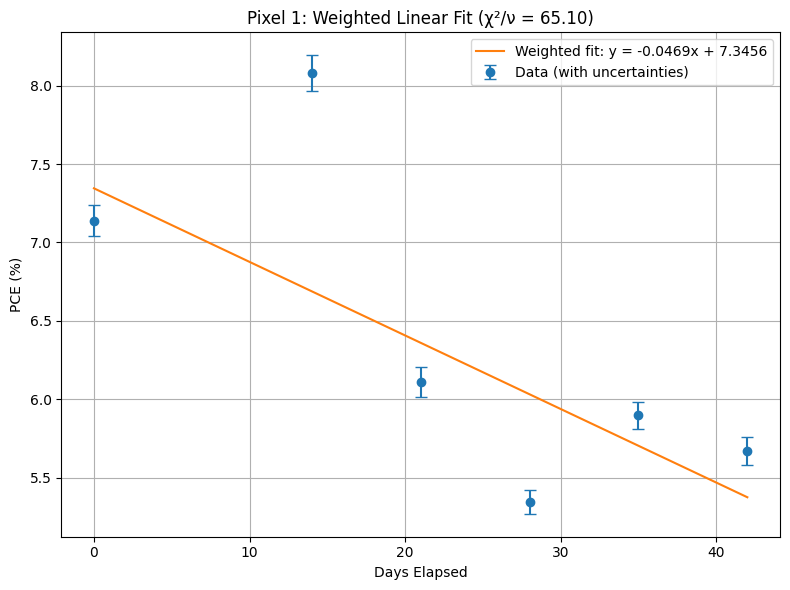

Pixel 2 — Weighted Linear Fit Results
  Slope (per day): 0.035886 ± 0.026320
  Intercept  (%):  5.620 ± 0.683
  Chi-squared:      513.276
  Reduced χ²:       128.319



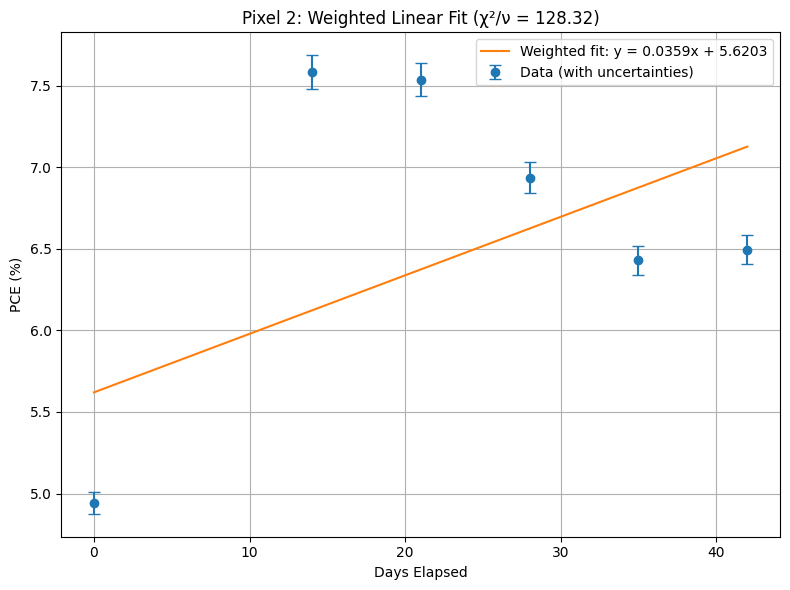

Pixel 3 — Weighted Linear Fit Results
  Slope (per day): 0.050438 ± 0.035399
  Intercept  (%):  5.806 ± 0.906
  Chi-squared:      837.559
  Reduced χ²:       209.390



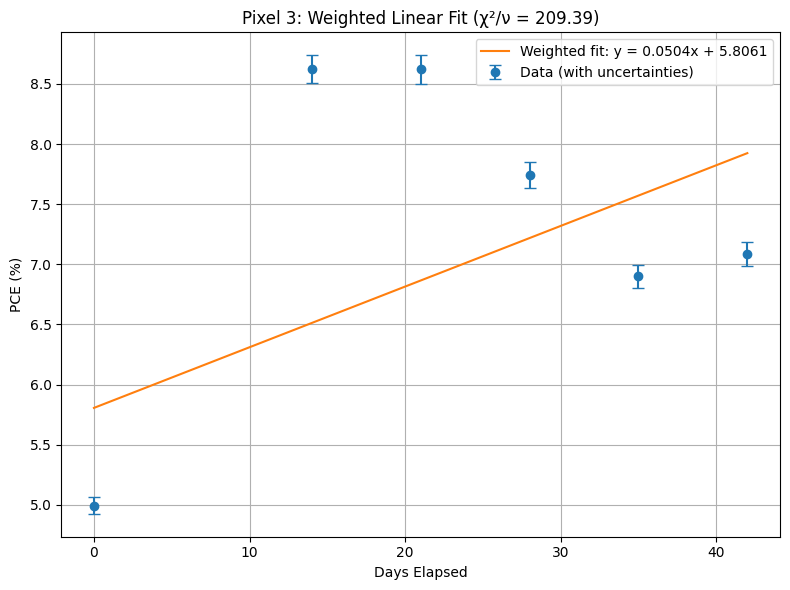

Pixel 4 — Weighted Linear Fit Results
  Slope (per day): -0.039517 ± 0.068355
  Intercept  (%):  9.655 ± 2.046
  Chi-squared:      1860.349
  Reduced χ²:       465.087



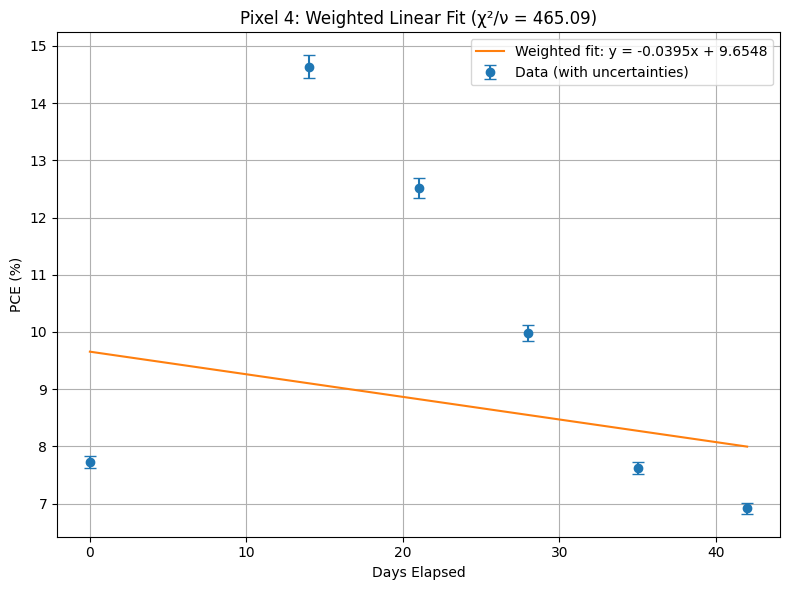

Pixel 5 — Weighted Linear Fit Results
  Slope (per day): 0.020989 ± 0.020076
  Intercept  (%):  5.644 ± 0.532
  Chi-squared:      305.145
  Reduced χ²:       76.286



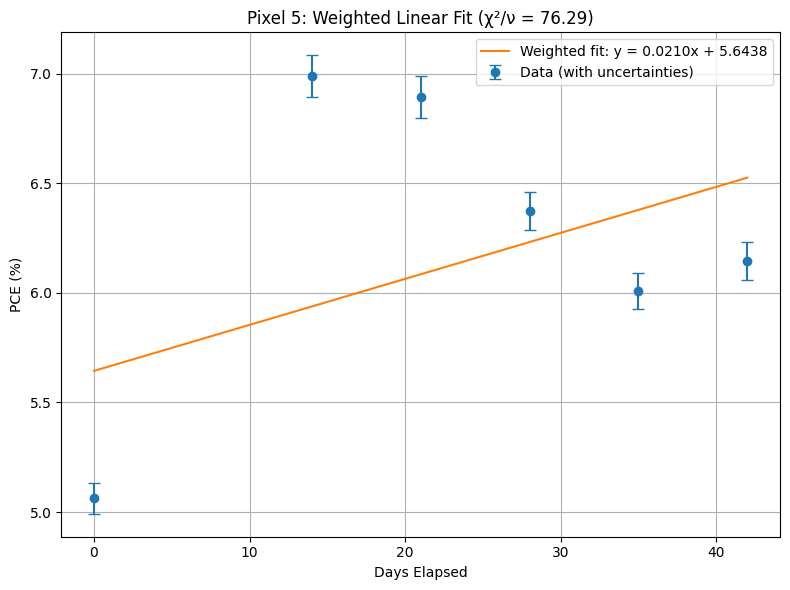

Pixel 6 — Weighted Linear Fit Results
  Slope (per day): -0.185965 ± 0.014296
  Intercept  (%):  19.695 ± 0.431
  Chi-squared:      20.133
  Reduced χ²:       5.033



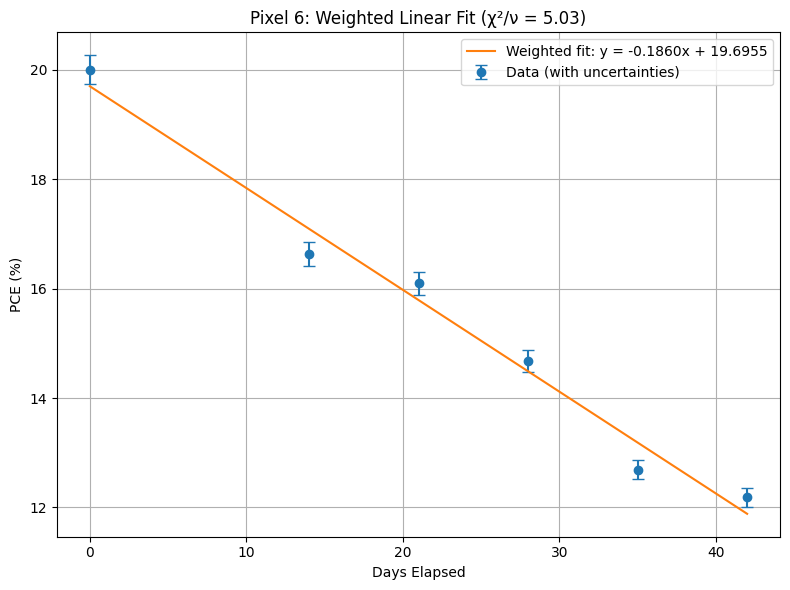

Pixel 7 — Weighted Linear Fit Results
  Slope (per day): 0.061358 ± 0.029801
  Intercept  (%):  5.209 ± 0.738
  Chi-squared:      658.973
  Reduced χ²:       164.743



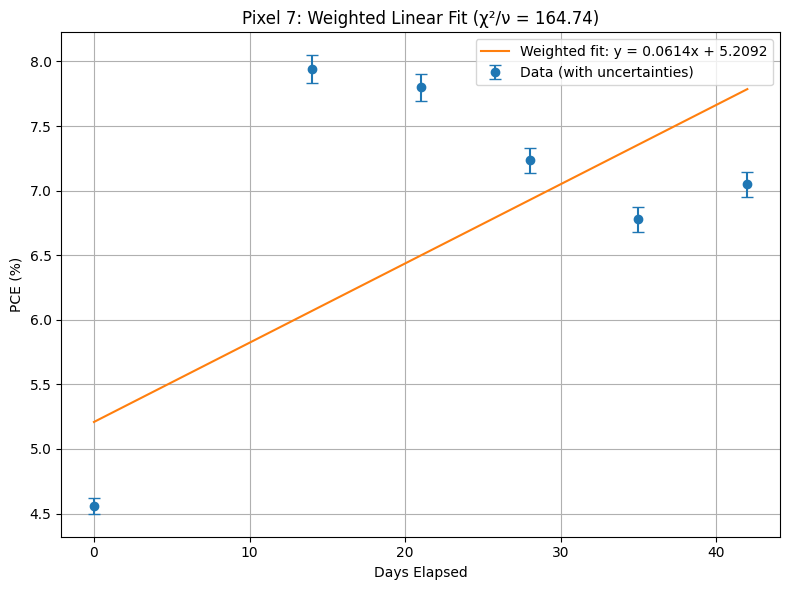

Pixel 8 — Weighted Linear Fit Results
  Slope (per day): 0.086098 ± 0.060523
  Intercept  (%):  7.772 ± 1.525
  Chi-squared:      1339.175
  Reduced χ²:       334.794



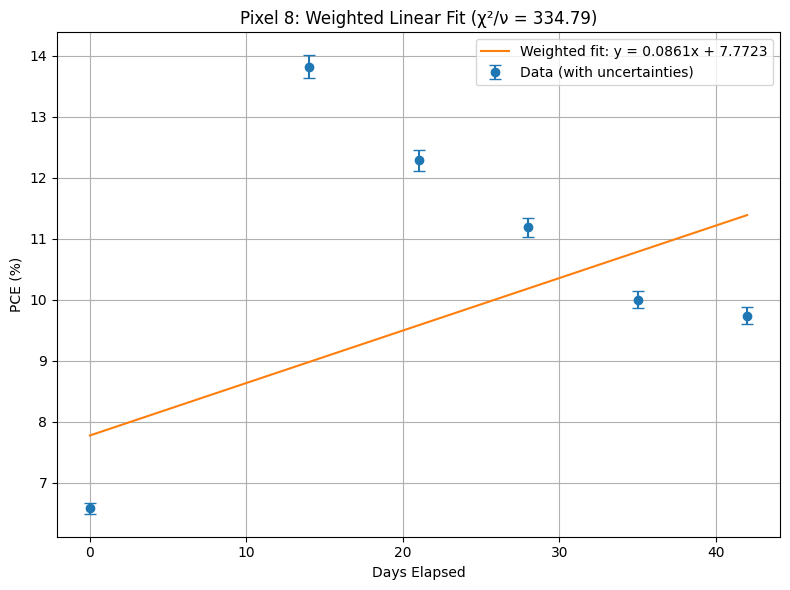

In [ ]:
# Weighted Linear Regression for All 8 Pixels

files = [
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week1/2026_01_27_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week3/2026_02_10_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week4/2026_02_17_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_jsc_pce_uncertainties_cellR22.csv",
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_jsc_pce_uncertainties_cellR22.csv",
]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

def weighted_linear_fit(x, y, yerr):
    yerr = np.asarray(yerr, float)
    mask = (yerr > 0) & np.isfinite(x) & np.isfinite(y)
    x, y, yerr = x[mask], y[mask], yerr[mask]

    X = np.vstack([x, np.ones_like(x)]).T
    w = 1.0 / (yerr**2)
    XTW = X.T * w
    XTWX = XTW @ X
    XTWy = XTW @ y

    beta = np.linalg.solve(XTWX, XTWy)
    cov  = np.linalg.inv(XTWX)

    y_fit = X @ beta
    resid = y - y_fit
    chi2 = np.sum((resid / yerr)**2)
    dof = max(len(y) - 2, 1)
    chi2_red = chi2 / dof

    cov_scaled = cov * chi2_red
    se = np.sqrt(np.diag(cov_scaled))

    m, b = float(beta[0]), float(beta[1])
    se_m, se_b = float(se[0]), float(se[1])
    return m, b, se_m, se_b, chi2, chi2_red, y_fit, resid

# Loop over all 8 pixels
for pixel_choice in range(1, 9):
    dfp = df[df["Pixel Number"] == pixel_choice].copy()
    if dfp.empty:
        print(f"Pixel {pixel_choice}: No data found, skipping.\n")
        continue

    x = (dfp["Time (hr)"].astype(float) / 24.0).to_numpy()
    y = dfp["PCE"].astype(float).to_numpy()
    yerr = dfp["PCE_uncertainty (%)"].astype(float).to_numpy()

    order = np.argsort(x)
    x, y, yerr = x[order], y[order], yerr[order]

    m, b, se_m, se_b, chi2, chi2_red, y_fit, resid = weighted_linear_fit(x, y, yerr)

    print(f"Pixel {pixel_choice} — Weighted Linear Fit Results")
    print(f"  Slope (per day): {m:.6f} ± {se_m:.6f}")
    print(f"  Intercept  (%):  {b:.3f} ± {se_b:.3f}")
    print(f"  Chi-squared:      {chi2:.3f}")
    print(f"  Reduced χ²:       {chi2_red:.3f}\n")

    xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    ys = m * xs + b

    plt.figure(figsize=(8, 6))
    plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4, label="Data (with uncertainties)")
    plt.plot(xs, ys, label=f"Weighted fit: y = {m:.4f}x + {b:.4f}")
    plt.xlabel("Days Elapsed")
    plt.ylabel("PCE (%)")
    plt.title(f"Pixel {pixel_choice}: Weighted Linear Fit (χ²/ν = {chi2_red:.2f})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Pixel 2 — Weighted Linear Fit Results
  Slope (per day): 0.035886 ± 0.026320
  Intercept  (%):  5.620 ± 0.683
  Chi-squared:      513.276
  Reduced χ²:       128.319


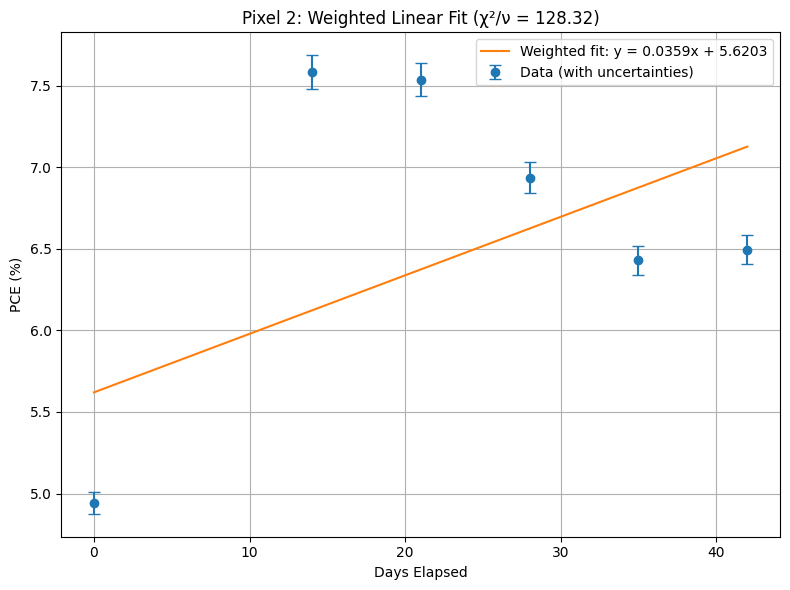

In [ ]:
# @title
# Weighted Linear Regression for a Single Pixel

# Be sure that you have imported pandas, numpy, and matplotlib
# which you should have already done for the J-V analysis

# Point to your CSVs (put them in the same folder as this notebook)
# Add one entry per week — you should have one CSV file for each data
# collection week. Be sure to update file names to match your dates/cell number.
files = [
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week1/2026_01_27_jsc_pce_uncertainties_cellR22.csv",  # baseline
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week3/2026_02_10_jsc_pce_uncertainties_cellR22.csv",  # Data Collection 1
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week4/2026_02_17_jsc_pce_uncertainties_cellR22.csv",  # Data Collection 2
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_jsc_pce_uncertainties_cellR22.csv",  # break week (TA data)
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_jsc_pce_uncertainties_cellR22.csv",  # Data Collection 3
    "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_jsc_pce_uncertainties_cellR22.csv",  # Data Collection 4 (this week)
]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Choose one pixel to analyze (valid: 1,2,3,4,5,6,7,8) and update the value
pixel_choice = 2

# 3) build x, y, yerr in the CORRECT units
dfp = df[df["Pixel Number"] == pixel_choice].copy()
if dfp.empty:
    raise ValueError(f"No rows found for Pixel {pixel_choice}.")

x = (dfp["Time (hr)"].astype(float) / 24.0).to_numpy()          # days elapsed
y = dfp["PCE"].astype(float).to_numpy()                          # PCE in percent
yerr = dfp["PCE_uncertainty (%)"].astype(float).to_numpy()       # absolute % uncertainty

# sort for clean plotting
order = np.argsort(x)
x, y, yerr = x[order], y[order], yerr[order]

# Weighted linear fit: y = m*x + b, weights = 1/σ^2
def weighted_linear_fit(x, y, yerr):
    # guard against zero/negative uncertainties
    yerr = np.asarray(yerr, float)
    mask = (yerr > 0) & np.isfinite(x) & np.isfinite(y)
    x, y, yerr = x[mask], y[mask], yerr[mask]

    # design matrix with columns [x, 1]
    X = np.vstack([x, np.ones_like(x)]).T
    w = 1.0 / (yerr**2)

    # Apply the weights directly to each row of our data
    # rather than creating a large matrix filled mostly with zeros.
    # This is mathematically equivalent to multiplying by the full
    # weight matrix but is much faster and easier to compute.
    XTW = X.T * w
    XTWX = XTW @ X
    XTWy = XTW @ y

    # parameters and (unscaled) covariance
    beta = np.linalg.solve(XTWX, XTWy)         # [m, b]
    cov  = np.linalg.inv(XTWX)                 # covariance up to scale

    # residuals and chi-squared
    y_fit = X @ beta
    resid = y - y_fit
    chi2 = np.sum((resid / yerr)**2)
    dof = max(len(y) - 2, 1)
    chi2_red = chi2 / dof

    # scale covariance by reduced chi^2 (robust if σ were misestimated)
    cov_scaled = cov * chi2_red
    se = np.sqrt(np.diag(cov_scaled))          # [σ_m, σ_b]

    m, b = float(beta[0]), float(beta[1])
    se_m, se_b = float(se[0]), float(se[1])
    return m, b, se_m, se_b, chi2, chi2_red, y_fit, resid

# Assign the output variables from the weighted linear fit function
m, b, se_m, se_b, chi2, chi2_red, y_fit, resid = weighted_linear_fit(x, y, yerr)

# Output fit results
print(f"Pixel {pixel_choice} — Weighted Linear Fit Results")
print(f"  Slope (per day): {m:.6f} ± {se_m:.6f}")
print(f"  Intercept  (%):  {b:.3f} ± {se_b:.3f}")
print(f"  Chi-squared:      {chi2:.3f}")
print(f"  Reduced χ²:       {chi2_red:.3f}")

# Make a figure with data + weighted fit with error bars
xs = np.linspace(np.nanmin(x), np.nanmax(x), 200) # Create evenly spaced x-values for plotting the fitted line
ys = m * xs + b

plt.figure(figsize=(8,6))
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4, label="Data (with uncertainties)")
plt.plot(xs, ys, label=f"Weighted fit: y = {m:.4f}x + {b:.4f}")
plt.xlabel("Days Elapsed"); plt.ylabel("PCE (%)")
plt.title(f"Pixel {pixel_choice}: Weighted Linear Fit (χ²/ν = {chi2_red:.2f})")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

### Residuals Analysis

Residuals show the difference between observed and predicted values from our model fit:

$$\text{Residual}_i = y_i - \hat{y}_i$$

Analyzing residuals helps us evaluate how well our model fits the data:

1. **Pattern**: Residuals should be randomly scattered around zero for a good model fit
2. **Magnitude**: Residuals should be small relative to the measurement uncertainties
3. **Trends**: Any visible pattern in residuals suggests the model may be missing important features in the data

When we plot residuals with error bars (using our measurement uncertainties), we can visually assess whether:
- The zero line (representing perfect prediction) falls within the error bars of most points
- There are systematic deviations that suggest our model is inadequate

Now, let's calculate the residuals from the weighted linear fit above:

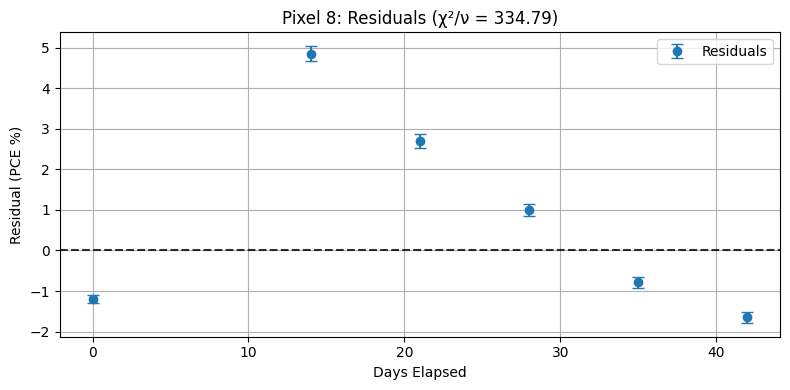

In [ ]:
# Residuals
residuals = y - y_fit

# Guard against zero/negative uncertainties
yerr_safe = np.where(yerr > 0, yerr, np.nan)
mask = ~np.isnan(residuals) & ~np.isnan(yerr_safe)

plt.figure(figsize=(8,4))
plt.errorbar(x, resid, yerr=yerr, fmt='o', capsize=4, label='Residuals')
plt.axhline(0, color='k', linestyle='--', alpha=0.8)
plt.xlabel("Days Elapsed"); plt.ylabel("Residual (PCE %)")
plt.title(f"Pixel {pixel_choice}: Residuals (χ²/ν = {chi2_red:.2f})")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

## Interpretation of Residuals:

1. The error bars represent the measurement uncertainties.
2. Residuals should be randomly scattered around zero for a good model fit.
3. A pattern in residuals suggests that a linear model is not appropriate.
4. If the error bars don't typically cross the zero line, this confirms the model is inadequate.


## Is a Linear Model Appropriate?

For reduced chi-squared, recall that:
- χ²/ν ≈ 1: Indicates a good fit with appropriate uncertainties
- χ²/ν < 1: May indicate overestimated uncertainties or overfitting
- χ²/ν > 1: May indicate underestimated uncertainties or a poor model fit


#### **Question 2**: Based on the plot of your residuals and your reduced chi-squared value, do you think that we chose the correct model for our analysis? Why or why not?

No, based on our plot I don't think this is the correct model. This is because, as it states above, a pattern in residuals suggest that a linear model is not a good fit. We can also see that this model is not randomly scattered around zero, and the error bars are not crossing the zero line.


There are two PhET simulations that may be useful for you to play around with to see how different curve fitting models apply to your data set. Have some fun with these:

- [Least Squares Regression](https://phet.colorado.edu/en/simulations/least-squares-regression)
- [Curve Fitting](https://phet.colorado.edu/en/simulations/curve-fitting)

## Two-Pixel Comparison: Are the Slopes the Same?

Your team may want to compare model fits for your Team project. Here, you will fit two different pixels with separate linear regression fits, then compare:
1) Each fit's parameters (slope/intercept with uncertainties) and reduced $\chi^{2}$
2) Whether the slopes are statistically different.


You will use the same weighted linear regression script to get the slope, intercept, and standard errors and then plot both data sets with their error bars (`PCE_unc (%)`), plus the two fit lines.
Then you will compute a simple z-test for slope difference:
  

  z = $\frac{m_A - m_B}{\sqrt{\sigma_{m_A}^2 + \sigma_{m_B}^2}}$

  
  As a rule of thumb, $|z| > 2$ suggests the slopes differ at roughly the 95% confidence level.

**Edit the code below with the two pixels you want to compare (valid: 1,2,3,4,5,6,7,8)**


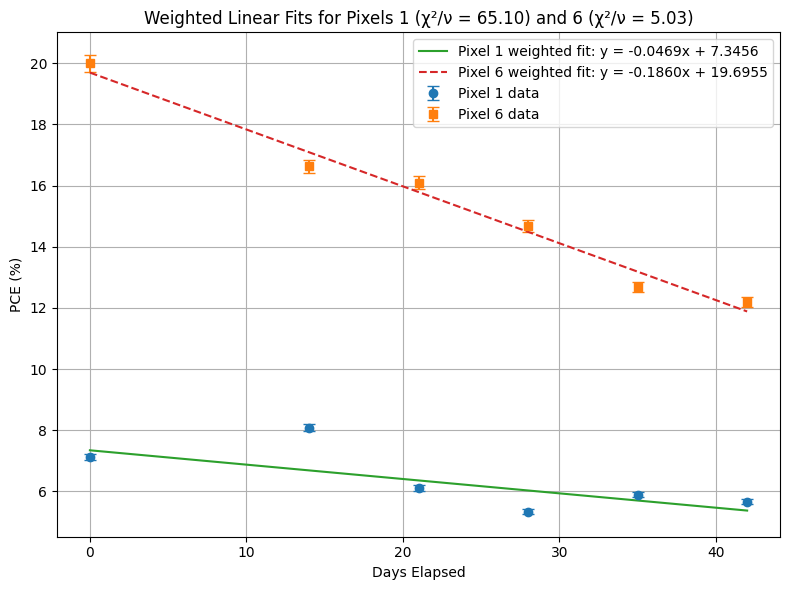

Pixel 1: slope = -0.046925 ± 0.022584, intercept = 7.346 ± 0.645, reduced χ² = 65.101
Pixel 6: slope = -0.185965 ± 0.014296, intercept = 19.695 ± 0.431, reduced χ² = 5.033

Slope comparison (z-test): z = 5.20


In [ ]:
# Two pixel comparison

# Choose two pixels to compare (valid: 1,2,3,4,5,6,7,8) and update the value
pixel_A, pixel_B = 1, 6

# build x,y,yerr for each pixel
def extract_pixel(df, pixel):
    d = df[df["Pixel Number"] == pixel].copy()
    x = (d["Time (hr)"].astype(float) / 24.0).to_numpy()
    y = d["PCE"].astype(float).to_numpy()
    yerr = d["PCE_uncertainty (%)"].astype(float).to_numpy()
    order = np.argsort(x)
    return x[order], y[order], yerr[order]

xA, yA, yerrA = extract_pixel(df, pixel_A)
xB, yB, yerrB = extract_pixel(df, pixel_B)

# weighted linear fit
def weighted_linear_fit(x, y, yerr):
    yerr = np.asarray(yerr, float)
    mask = (yerr > 0) & np.isfinite(x) & np.isfinite(y)
    x, y, yerr = x[mask], y[mask], yerr[mask]

    X = np.vstack([x, np.ones_like(x)]).T
    w = 1.0 / (yerr**2)

    XTW = X.T * w
    XTWX = XTW @ X
    XTWy = XTW @ y

    beta = np.linalg.solve(XTWX, XTWy)
    cov = np.linalg.inv(XTWX)

    yfit = X @ beta
    resid = y - yfit
    chi2 = np.sum((resid / yerr)**2)
    dof = max(len(y) - 2, 1)
    chi2_red = chi2 / dof
    cov_scaled = cov * chi2_red
    se = np.sqrt(np.diag(cov_scaled))

    m, b = float(beta[0]), float(beta[1])
    se_m, se_b = float(se[0]), float(se[1])
    return m, b, se_m, se_b, chi2, chi2_red, yfit, resid

mA, bA, se_mA, se_bA, chi2A, chi2_redA, yfitA, residA = weighted_linear_fit(xA, yA, yerrA)
mB, bB, se_mB, se_bB, chi2B, chi2_redB, yfitB, residB = weighted_linear_fit(xB, yB, yerrB)

# Calculate value from z-test
z = abs(mA - mB) / np.sqrt(se_mA**2 + se_mB**2)

# Plot both fits on one graph
plt.figure(figsize=(8,6))
plt.errorbar(xA, yA, yerr=yerrA, fmt='o', capsize=4, label=f'Pixel {pixel_A} data')
plt.errorbar(xB, yB, yerr=yerrB, fmt='s', capsize=4, label=f'Pixel {pixel_B} data')

xfit = np.linspace(min(np.min(xA), np.min(xB)), max(np.max(xA), np.max(xB)), 200)
plt.plot(xfit, mA*xfit + bA, '-', label=f'Pixel {pixel_A} weighted fit: y = {mA:.4f}x + {bA:.4f}')
plt.plot(xfit, mB*xfit + bB, '--', label=f'Pixel {pixel_B} weighted fit: y = {mB:.4f}x + {bB:.4f}')


plt.xlabel("Days Elapsed")
plt.ylabel("PCE (%)")
plt.title(f"Weighted Linear Fits for Pixels {pixel_A} (χ²/ν = {chi2_redA:.2f}) and {pixel_B} (χ²/ν = {chi2_redB:.2f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output fits and z-test results
print(f"Pixel {pixel_A}: slope = {mA:.6f} ± {se_mA:.6f}, intercept = {bA:.3f} ± {se_bA:.3f}, reduced χ² = {chi2_redA:.3f}")
print(f"Pixel {pixel_B}: slope = {mB:.6f} ± {se_mB:.6f}, intercept = {bB:.3f} ± {se_bB:.3f}, reduced χ² = {chi2_redB:.3f}")

print(f"\nSlope comparison (z-test): z = {z:.2f}")

  As a rule of thumb, $|z| > 2$ suggests the slopes differ at roughly the 95% confidence level.
  
  **NOTE:**  Even if two slopes appear "significantly different" by this rule, that conclusion only makes sense **if each linear model adequately describes its data.**  Keep in mind that large reduced chi-squared (χ²/ν) values mean the scatter or non-linearity in the data dominates over the measurement uncertainties, so any small slope differences should be viewed cautiously.


#### **Question 3:** What does your z-test result tell you about the relationship between the two slopes?

Our z-test results tell us that our slopes differ at a 95% confidence level. Our z = 5.20, and since 5.20 > 2, then we know this conclusion to be true.

### Residuals for the Two Fits

After comparing the two regression lines, check the residuals.

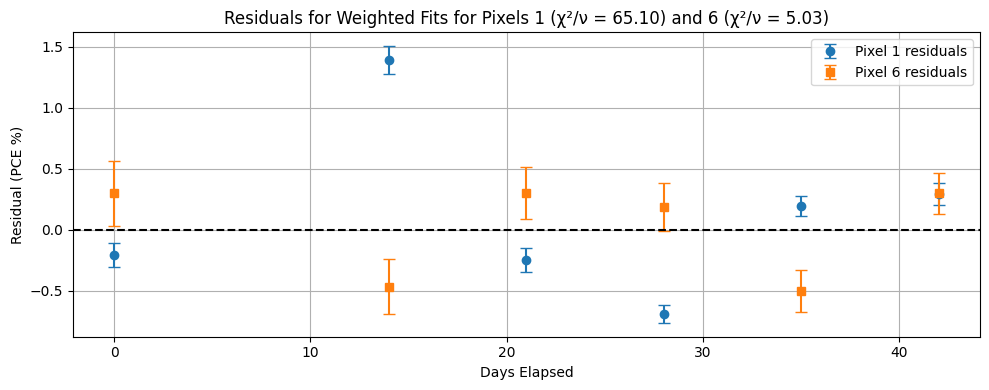

In [ ]:
# The residual values were calculated in the weight fits above, so you only
# need to create the plot.

plt.figure(figsize=(10,4))
plt.errorbar(xA, residA, yerr=yerrA, fmt='o', capsize=4, label=f'Pixel {pixel_A} residuals')
plt.errorbar(xB, residB, yerr=yerrB, fmt='s', capsize=4, label=f'Pixel {pixel_B} residuals')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Days Elapsed")
plt.ylabel("Residual (PCE %)")
plt.title(f"Residuals for Weighted Fits for Pixels {pixel_A} (χ²/ν = {chi2_redA:.2f}) and {pixel_B} (χ²/ν = {chi2_redB:.2f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Question 4:** Based on what you have seen from both the single- and two-pixel fits, do you think a linear model is the right choice for analyzing how PCE changes with time?

#### If yes, explain why. If no, what other types of models or approaches might better describe the trend?


No, a linear model would not be a good choice. This is because for both pixels we are getting a pattern (a curve). We know that when residuals have patterns than they are not accurately being describe with the model. I would suggest a decay model to show the PCE degradation more accurately.

**For potential future use:** Here is a [link to some code](https://docs.google.com/document/d/19uAAwrHFudwfoeKk0ZGU0_OJs_ICMrf1EfBkjRnfI_Q/edit?usp=sharing) that loops through all 8 pixels, calculating and plotting weighted linear fits and residuals.

# **Author Contributions (required)**
Madelyn - Contributed to questions and data collection.
Greg - Contributed to code and questions.
Jay - Contributed to code and data collection.



# **Use of AI (required)**



1.   How your team used AI tools: Describe the specific tasks where AI-assisted tools were involved. For example, did AI help with writing, debugging, optimizing, or refining your code? Which components of the analysis did your team use AI on?

Chat GPT was used to convert the 'show one cell' graph to loop and create 8 graphs, one for each cell.

2.   When your team used AI tools: Specify at what stage(s) of your programming process you used AI. Was it during initial code development, troubleshooting, etc.?

It was strictly used for data analysis

3.   Which AI tools your team used: Identify the AI tools or platforms your team consulted (e.g., ChatGPT, GitHub Copilot, etc.).

Chat GPT


